<a href="https://colab.research.google.com/github/alizasultanaesd-png/skill-morph-work/blob/main/Laggged_multi_hazard_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laggged multi hazard analysis**

2: mutli-hazard figures:

-histrogram for monthly precipitation for 2 study regions

-histrogram for monthly maximum temperature for 2 study regions

-pair-wise plot for the following combinations:

-(wind gust - max. temperature)

-(wind gust - precipitation)

-(precipitation - max temperature)



3: multi-hazard figures with lag:

-do the same, but now with precipitation from the previous month compared to wind gust and temperature from current month



In [ ]:
!pip install xarray netCDF4 matplotlib
!pip install cartopy

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import netCDF4 as nc
import pandas as pd
import sys
import xarray as xr
import geopandas as gpd
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 48.9 MB/s eta 0:00:00


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive



Mounted at /content/drive
'Colab Notebooks'		      data_stream-moda_stepType-avgua.nc
 data				      data_stream-oper_stepType-instant.nc
 datasets			      diabetes.csv
 data_stream-moda_stepType-avgad.nc   Housing.csv
 data_stream-moda_stepType-avgid.nc


In [ ]:
import xarray as xr

# NetCDF file load
ds_precip = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgad.nc")   # tp (monthly)
ds_wind   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgid.nc")   # i10fg
ds_temp   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgua.nc")   # t2m

# Variables list for each dataset
print("Precipitation dataset variables:", ds_precip.variables)
print("Wind dataset variables:", ds_wind.variables)
print("Temperature dataset variables:", ds_temp.variables)

# Dataset summary
print(ds_precip)
print(ds_wind)
print(ds_temp)


Precipitation dataset variables: Frozen({'tp': <xarray.Variable (valid_time: 60, latitude: 41, longitude: 41)> Size: 403kB
[100860 values with dtype=float32]
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1681
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            avgad
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0, 'number': <xarray.Variable ()> Size: 8B
[1 values with dtype=int64]
Attributes:
    long_name:      ensemble member numerical id
    units:          1
  

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving bgd_admin1.geojson to bgd_admin1.geojson
Saving bgd_admin2.geojson to bgd_admin2.geojson
Saving bgd_admin3.geojson to bgd_admin3.geojson


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_stream-moda_stepType-avgad.nc to data_stream-moda_stepType-avgad.nc
Saving data_stream-moda_stepType-avgid.nc to data_stream-moda_stepType-avgid.nc
Saving data_stream-moda_stepType-avgua.nc to data_stream-moda_stepType-avgua.nc


In [ ]:
import warnings
warnings.filterwarnings("ignore")

# DataFrame
divisions = pd.DataFrame({
    "Division": ["Khulna", "Barishal", "Dhaka", "Chittagong"],
    "Latitude": [22.75, 22.70, 23.75, 22.35],
    "Longitude": [89.75, 90.35, 90.40, 91.80]
})

print(divisions.columns)


Index(['Division', 'Latitude', 'Longitude'], dtype='object')


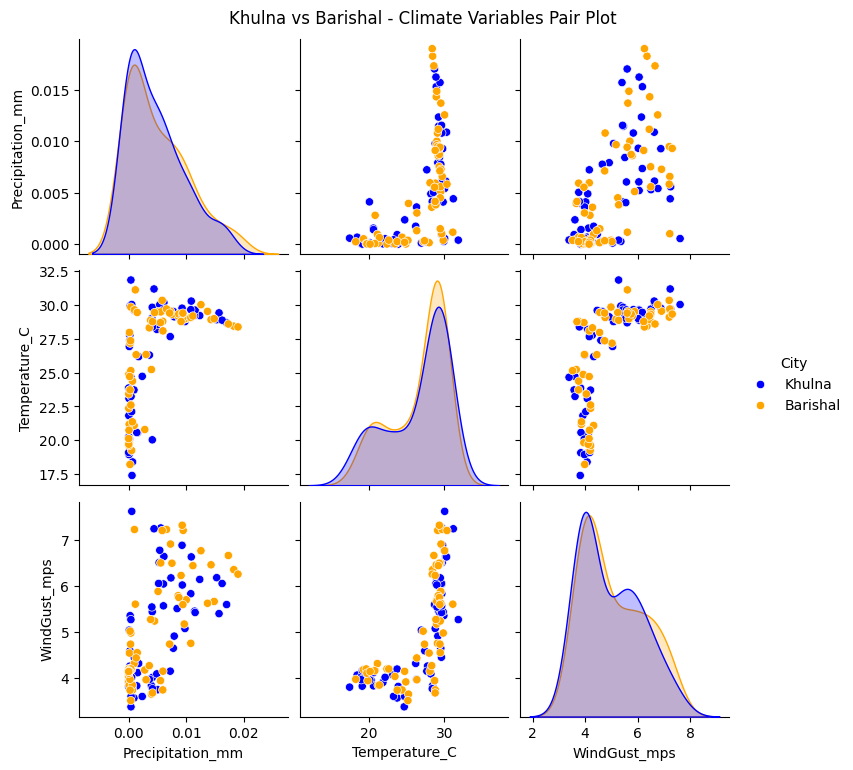

In [ ]:
import xarray as xr
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === Load datasets ===
ds_precip = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgad.nc")   # tp (monthly)
ds_wind   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgid.nc")   # i10fg (monthly/diurnal avg)
ds_temp   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgua.nc")   # t2m (annual avg)

# === Locations ===
lat_khulna, lon_khulna = 22.8, 89.5
lat_barishal, lon_barishal = 22.7, 90.4

# === Extract data ===
precip_khulna = ds_precip["tp"].sel(latitude=lat_khulna, longitude=lon_khulna, method="nearest").to_pandas()
precip_barishal = ds_precip["tp"].sel(latitude=lat_barishal, longitude=lon_barishal, method="nearest").to_pandas()

wind_khulna = ds_wind["i10fg"].sel(latitude=lat_khulna, longitude=lon_khulna, method="nearest").to_pandas()
wind_barishal = ds_wind["i10fg"].sel(latitude=lat_barishal, longitude=lon_barishal, method="nearest").to_pandas()

temp_khulna = ds_temp["t2m"].sel(latitude=lat_khulna, longitude=lon_khulna, method="nearest").to_pandas() - 273.15
temp_barishal = ds_temp["t2m"].sel(latitude=lat_barishal, longitude=lon_barishal, method="nearest").to_pandas() - 273.15

# === Align time index (reindex to monthly for consistency) ===
common_index = precip_khulna.index  # suppose precip er monthly index is right
wind_khulna = wind_khulna.reindex(common_index, method="nearest")
wind_barishal = wind_barishal.reindex(common_index, method="nearest")
temp_khulna = temp_khulna.reindex(common_index, method="nearest")
temp_barishal = temp_barishal.reindex(common_index, method="nearest")

# === Build DataFrame ===
df = pd.DataFrame({
    "Precipitation_mm": list(precip_khulna.values) + list(precip_barishal.values),
    "Temperature_C": list(temp_khulna.values) + list(temp_barishal.values),
    "WindGust_mps": list(wind_khulna.values) + list(wind_barishal.values),
    "City": ["Khulna"]*len(precip_khulna) + ["Barishal"]*len(precip_barishal)
}, index=list(common_index) + list(common_index))

# === Pair plot ===
sns.pairplot(df, hue="City", diag_kind="kde",
             vars=["Precipitation_mm","Temperature_C","WindGust_mps"],
             palette={"Khulna":"blue","Barishal":"orange"})
plt.suptitle("Khulna vs Barishal - Climate Variables Pair Plot", y=1.02)
plt.show()


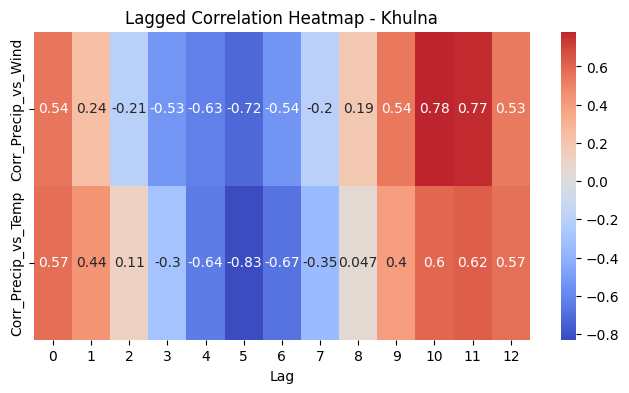

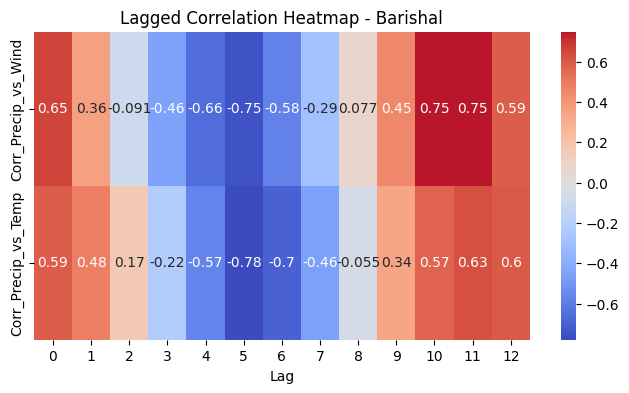

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df: Precipitation_mm, WindGust_mps, Temperature_C, City

def lagged_corr_heatmap(df, city, max_lag=12):
    subset = df[df["City"] == city].dropna()
    results = {"Lag": [], "Corr_Precip_vs_Wind": [], "Corr_Precip_vs_Temp": []}

    for lag in range(0, max_lag+1):
        lagged_precip = subset["Precipitation_mm"].shift(lag)
        corr_wind = lagged_precip.corr(subset["WindGust_mps"])
        corr_temp = lagged_precip.corr(subset["Temperature_C"])
        results["Lag"].append(lag)
        results["Corr_Precip_vs_Wind"].append(corr_wind)
        results["Corr_Precip_vs_Temp"].append(corr_temp)

    corr_df = pd.DataFrame(results).set_index("Lag")

    plt.figure(figsize=(8,4))
    sns.heatmap(corr_df.T, annot=True, cmap="coolwarm", center=0)
    plt.title(f"Lagged Correlation Heatmap - {city}")
    plt.show()

# Run for both cities
lagged_corr_heatmap(df, "Khulna")
lagged_corr_heatmap(df, "Barishal")


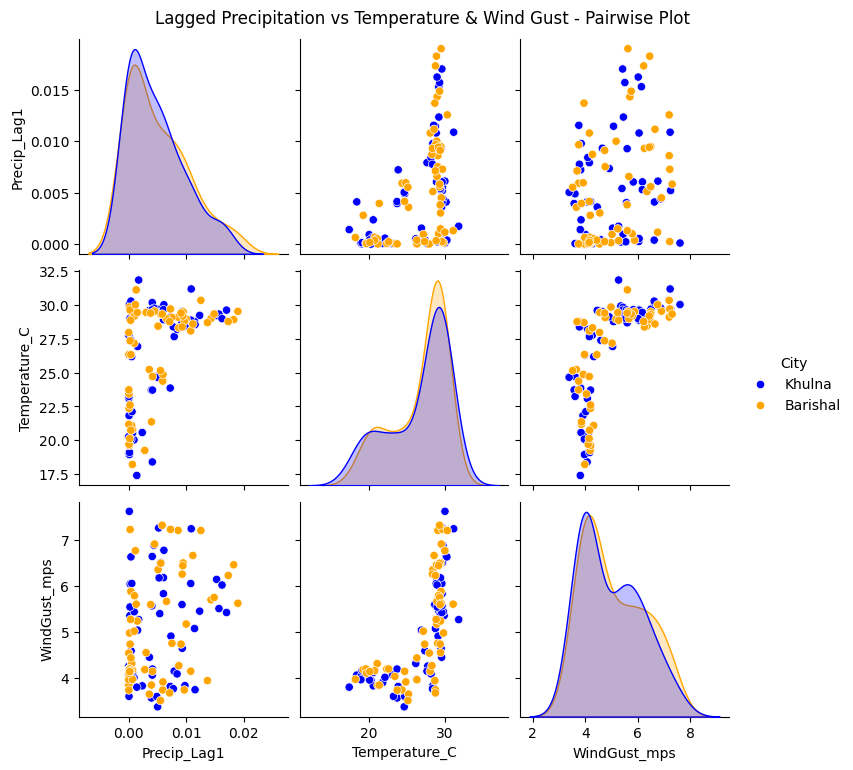

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lagged precipitation addition
df["Precip_Lag1"] = df.groupby("City")["Precipitation_mm"].shift(1)

# only keep non‑NA
df_clean = df.dropna(subset=["Precip_Lag1","Temperature_C","WindGust_mps"])

# Pairplot: Lagged Precipitation vs Temperature & Wind Gust
sns.pairplot(df_clean, hue="City", diag_kind="kde",
             vars=["Precip_Lag1","Temperature_C","WindGust_mps"],
             palette={"Khulna":"blue","Barishal":"orange"})
plt.suptitle("Lagged Precipitation vs Temperature & Wind Gust - Pairwise Plot", y=1.02)
plt.show()


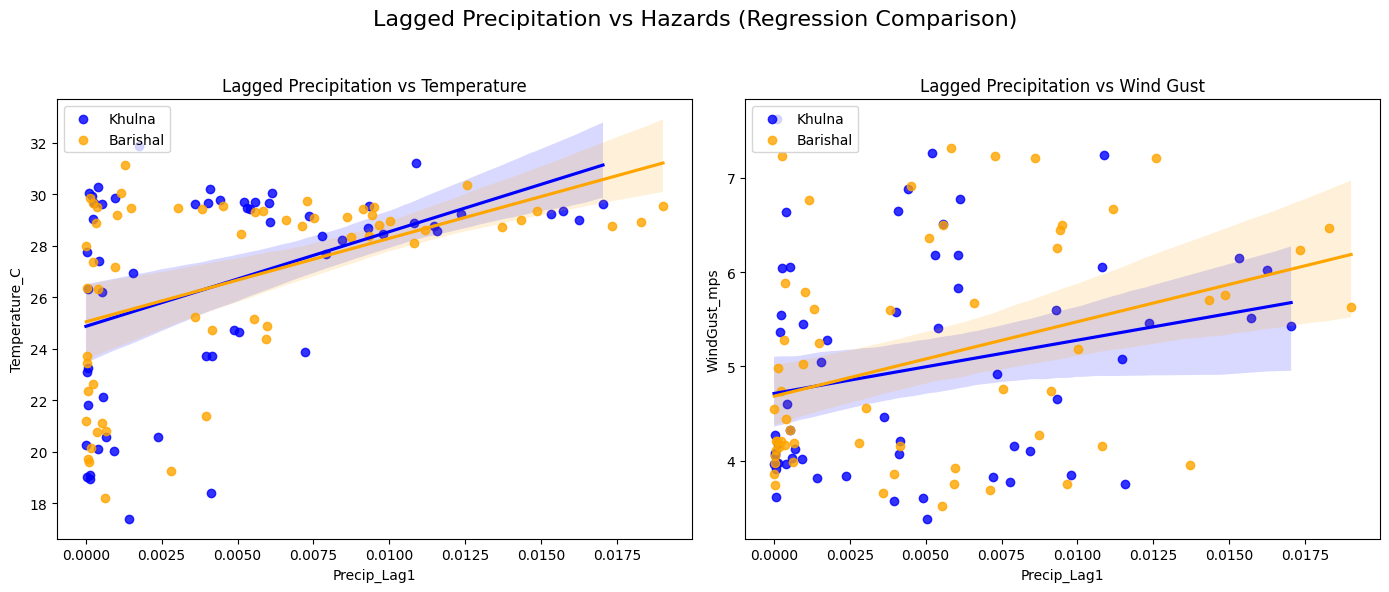

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lagged precipitation addition
df["Precip_Lag1"] = df.groupby("City")["Precipitation_mm"].shift(1)
df_clean = df.dropna(subset=["Precip_Lag1","Temperature_C","WindGust_mps"])

fig, axes = plt.subplots(1, 2, figsize=(14,6))

# 1. Regression plot: Lagged Precip vs Temperature
sns.regplot(data=df_clean[df_clean["City"]=="Khulna"],
            x="Precip_Lag1", y="Temperature_C", ax=axes[0],
            scatter_kws={"color":"blue", "marker":"o"}, line_kws={"color":"blue"}, label="Khulna")
sns.regplot(data=df_clean[df_clean["City"]=="Barishal"],
            x="Precip_Lag1", y="Temperature_C", ax=axes[0],
            scatter_kws={"color":"orange", "marker":"s"}, line_kws={"color":"orange"}, label="Barishal")
axes[0].set_title("Lagged Precipitation vs Temperature")
axes[0].legend(loc="upper left", frameon=True)

# 2. Regression plot: Lagged Precip vs Wind Gust
sns.regplot(data=df_clean[df_clean["City"]=="Khulna"],
            x="Precip_Lag1", y="WindGust_mps", ax=axes[1],
            scatter_kws={"color":"blue", "marker":"o"}, line_kws={"color":"blue"}, label="Khulna")
sns.regplot(data=df_clean[df_clean["City"]=="Barishal"],
            x="Precip_Lag1", y="WindGust_mps", ax=axes[1],
            scatter_kws={"color":"orange", "marker":"s"}, line_kws={"color":"orange"}, label="Barishal")
axes[1].set_title("Lagged Precipitation vs Wind Gust")
axes[1].legend(loc="upper left", frameon=True)

plt.suptitle("Lagged Precipitation vs Hazards (Regression Comparison)", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()


In [ ]:
import xarray as xr

# =========================
# Load datasets
# =========================
ds_precip = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgad.nc")   # Precipitation
ds_wind   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgid.nc")   # Wind gust
ds_temp   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgua.nc")   # Temperature

# =========================
# Extract variables
# =========================
t2m   = ds_temp['t2m'] - 273.15   # Kelvin → °C
tp    = ds_precip['tp']           # Total precipitation (m)
i10fg = ds_wind['i10fg']          # Instantaneous 10m wind gust (m/s)

print("Variables loaded successfully:", t2m.name, tp.name, i10fg.name)


Variables loaded successfully: t2m tp i10fg


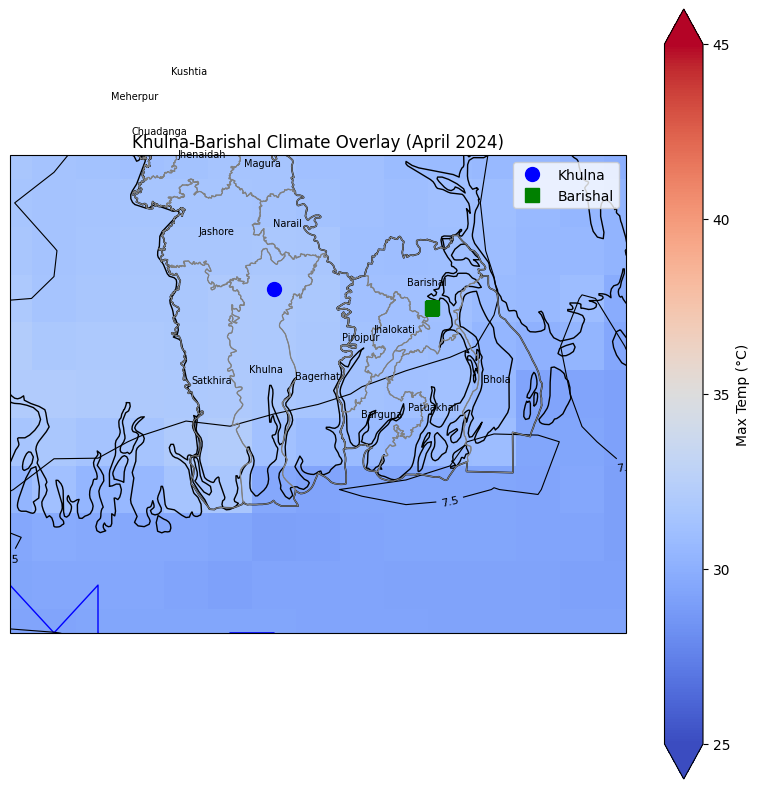

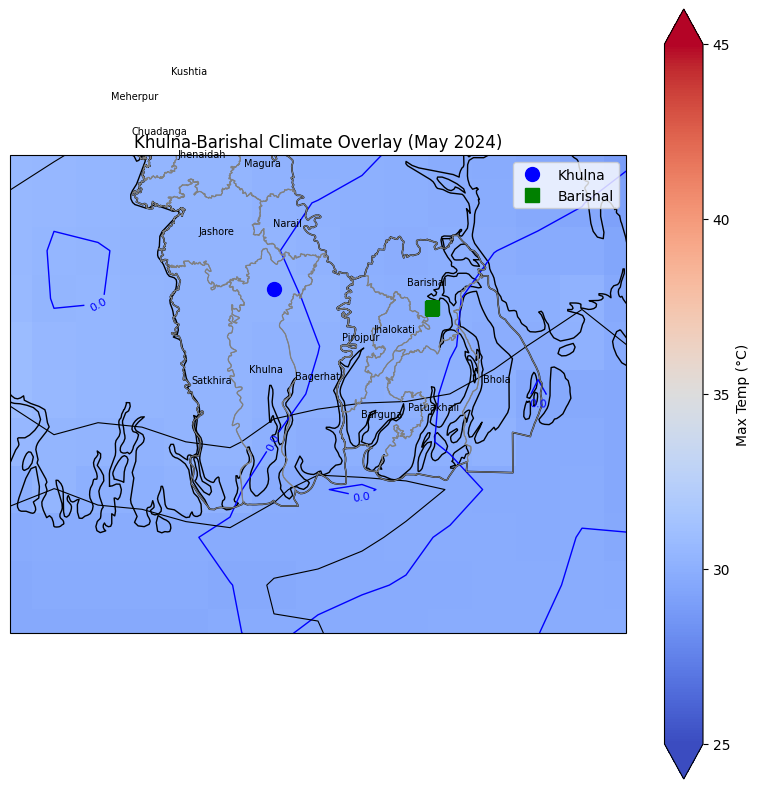

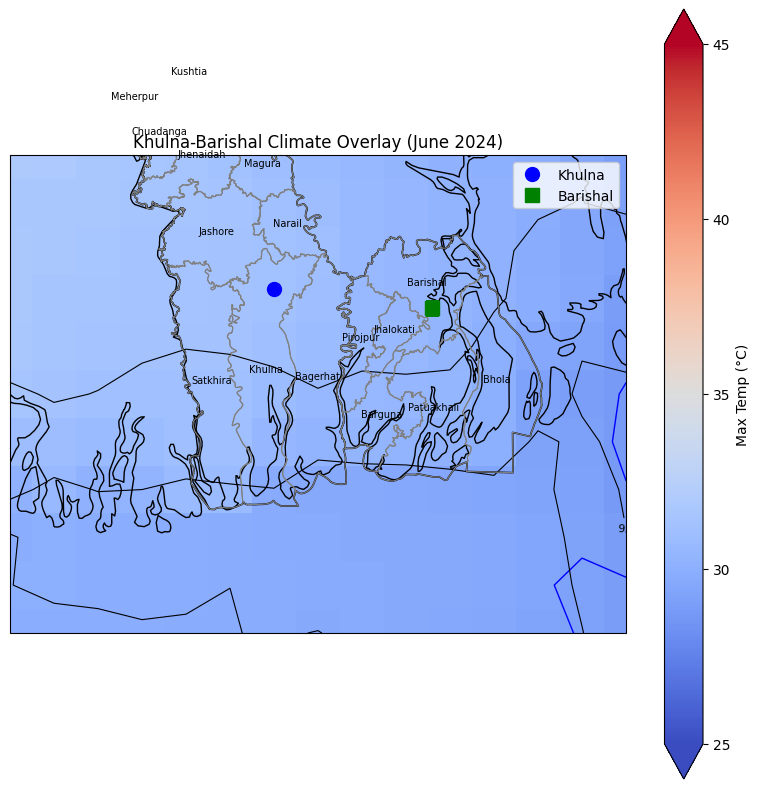

In [ ]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# =========================
# Load datasets
# =========================
ds_temp   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgua.nc")   # Temperature
ds_precip = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgad.nc")   # Precipitation
ds_wind   = xr.open_dataset("/content/drive/MyDrive/data_stream-moda_stepType-avgid.nc")   # Wind gust

# =========================
# Extract variables
# =========================
t2m   = ds_temp['t2m'] - 273.15   # Kelvin → °C
tp    = ds_precip['tp']           # Precipitation (m)
i10fg = ds_wind['i10fg']          # Wind gust (m/s)

# =========================
# Division + District boundaries
# =========================
divisions = gpd.read_file("bgd_admin1.geojson")
districts = gpd.read_file("bgd_admin2.geojson")   # এখানে district shapefile দরকার

target_divs = divisions[divisions['adm1_name'].isin(["Khulna","Barishal"])]
target_districts = districts[districts['adm1_name'].isin(["Khulna","Barishal"])]

# =========================
# Monthly ranges
# =========================
months = {
    "April": ("2024-04-01", "2024-04-30"),
    "May": ("2024-05-01", "2024-05-31"),
    "June": ("2024-06-01", "2024-06-30")
}

vmin_fixed, vmax_fixed = 25, 45

for month_name, (start_date, end_date) in months.items():
    subset = slice(start_date, end_date)

    # Temperature (max over month)
    t2m_month = t2m.sel(valid_time=subset)
    t2m_max = t2m_month.max(dim='valid_time')

    # Precipitation (sum over month)
    tp_month = tp.sel(valid_time=subset).sum(dim='valid_time')

    # Wind gust (mean over month)
    wind_month = i10fg.sel(valid_time=subset).mean(dim='valid_time')

    lon, lat = np.meshgrid(ds_temp.longitude, ds_temp.latitude)

    fig, ax = plt.subplots(1,1, figsize=(8,8), subplot_kw={'projection':ccrs.PlateCarree()})

    ax.set_extent([88, 91.5, 21, 23.5], crs=ccrs.PlateCarree())
    ax.coastlines(); ax.add_feature(cfeature.BORDERS, linestyle='-')

    # Temperature overlay
    mesh = ax.pcolormesh(lon, lat, t2m_max, cmap='coolwarm',
                         vmin=vmin_fixed, vmax=vmax_fixed, transform=ccrs.PlateCarree())

    # Precipitation overlay
    precip_contour = ax.contour(lon, lat, tp_month, levels=5,
                                colors='blue', linewidths=1, transform=ccrs.PlateCarree())
    ax.clabel(precip_contour, inline=True, fontsize=8, fmt="%.1f")

    # Wind gust overlay
    wind_contour = ax.contour(lon, lat, wind_month, levels=5,
                              colors='black', linewidths=0.8, transform=ccrs.PlateCarree())
    ax.clabel(wind_contour, inline=True, fontsize=8, fmt="%.1f")

    # Division + District boundaries
    target_divs.boundary.plot(ax=ax, edgecolor="black", linewidth=1.2)
    target_districts.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.8)

    # District labels
    for idx, row in target_districts.iterrows():
        ax.text(row.geometry.centroid.x, row.geometry.centroid.y,
                row['adm2_name'], fontsize=7, ha='center', transform=ccrs.PlateCarree())

    # City markers
    ax.plot(89.5, 22.8, 'o', markersize=10, color='blue', label="Khulna")
    ax.plot(90.4, 22.7, 's', markersize=10, color='green', label="Barishal")
    ax.legend(loc="upper right")

    ax.set_title(f"Khulna-Barishal Climate Overlay ({month_name} 2024)")

    # Colorbar
    cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', extend='both')
    cbar.set_label("Max Temp (°C)")
    cbar.set_ticks(np.arange(vmin_fixed, vmax_fixed+1, 5))

    plt.tight_layout()
    plt.show()


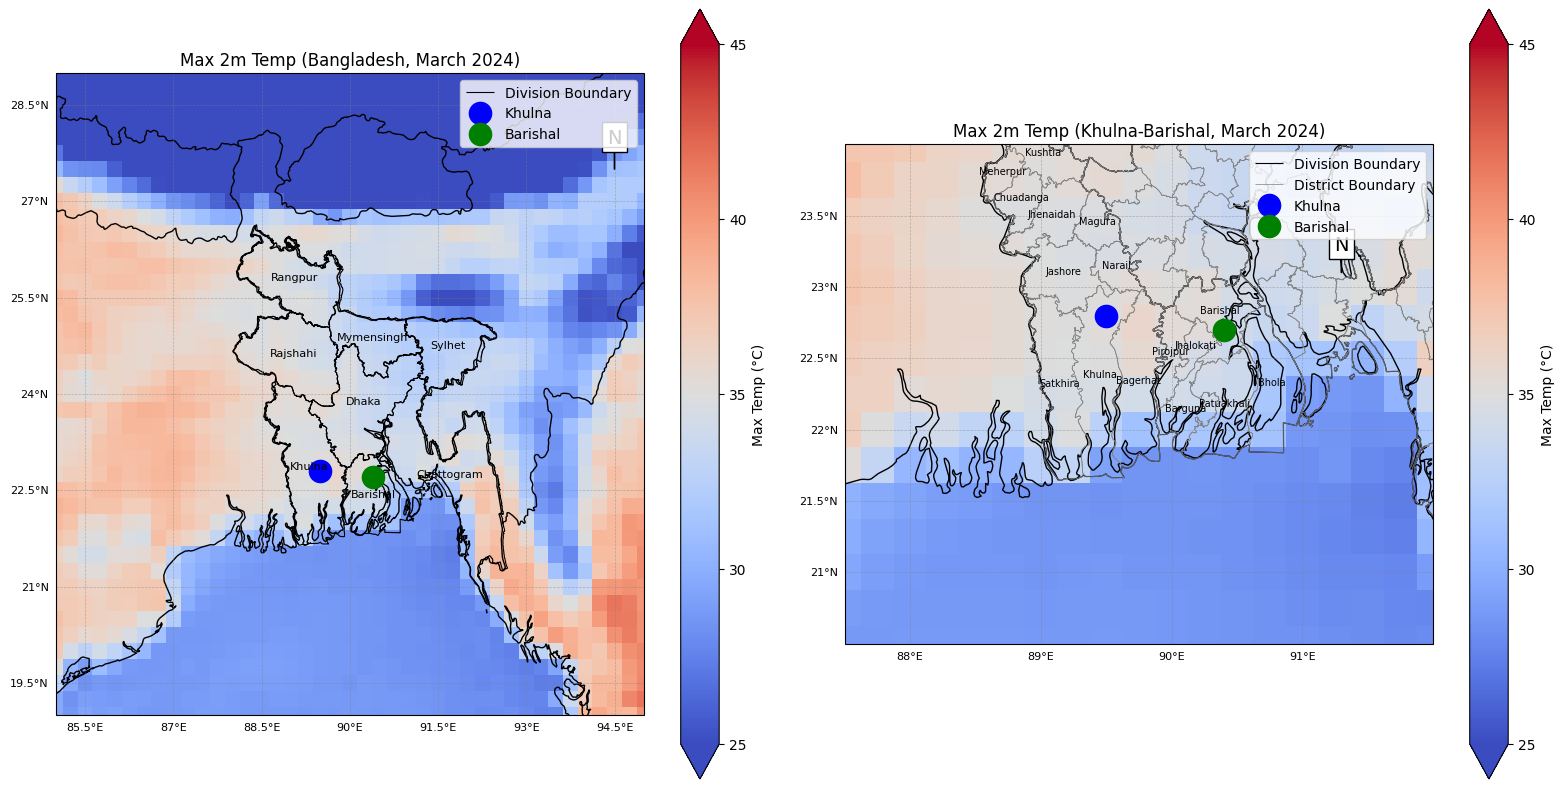

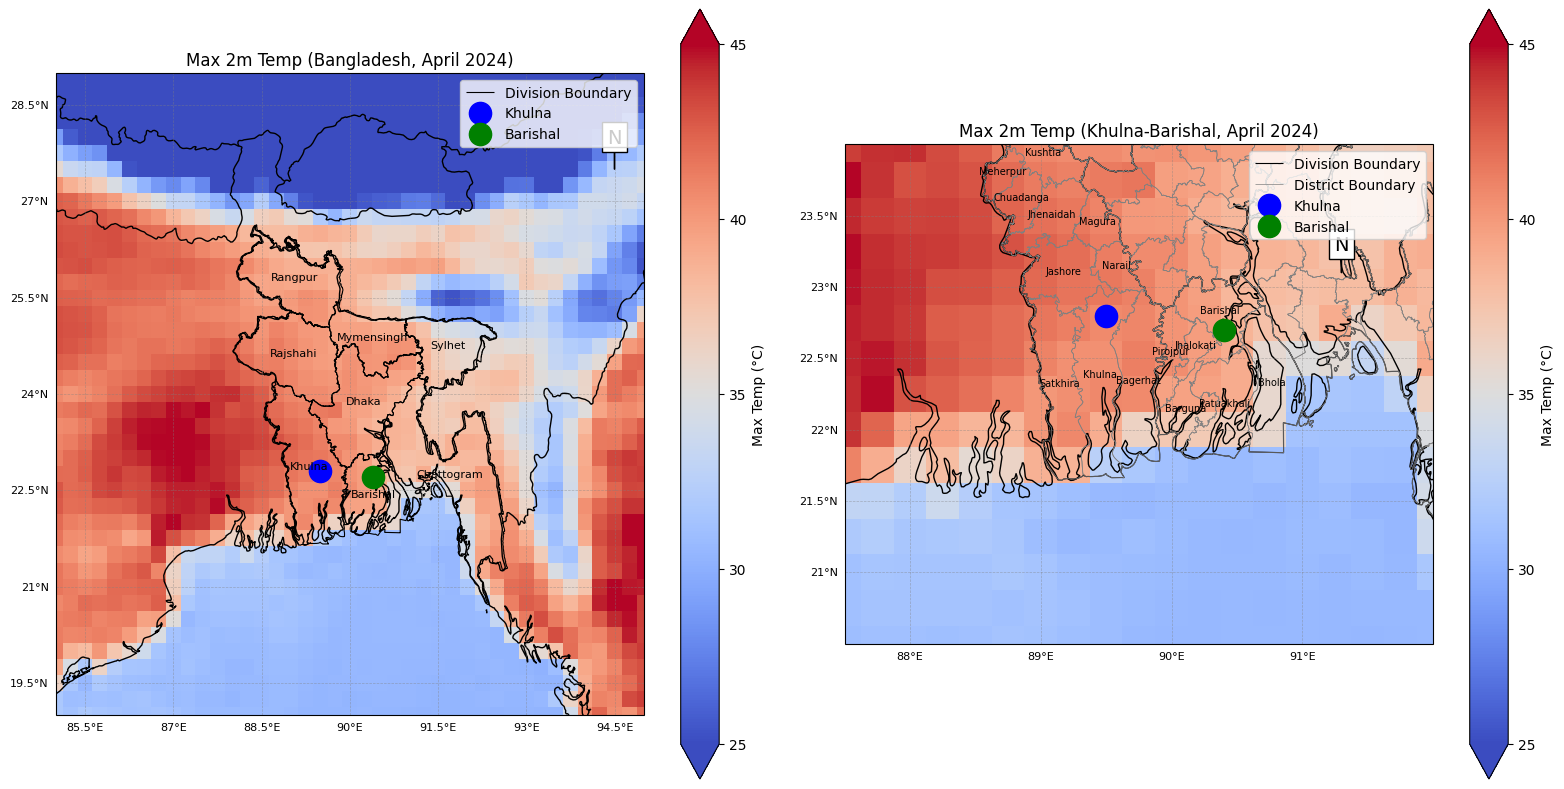

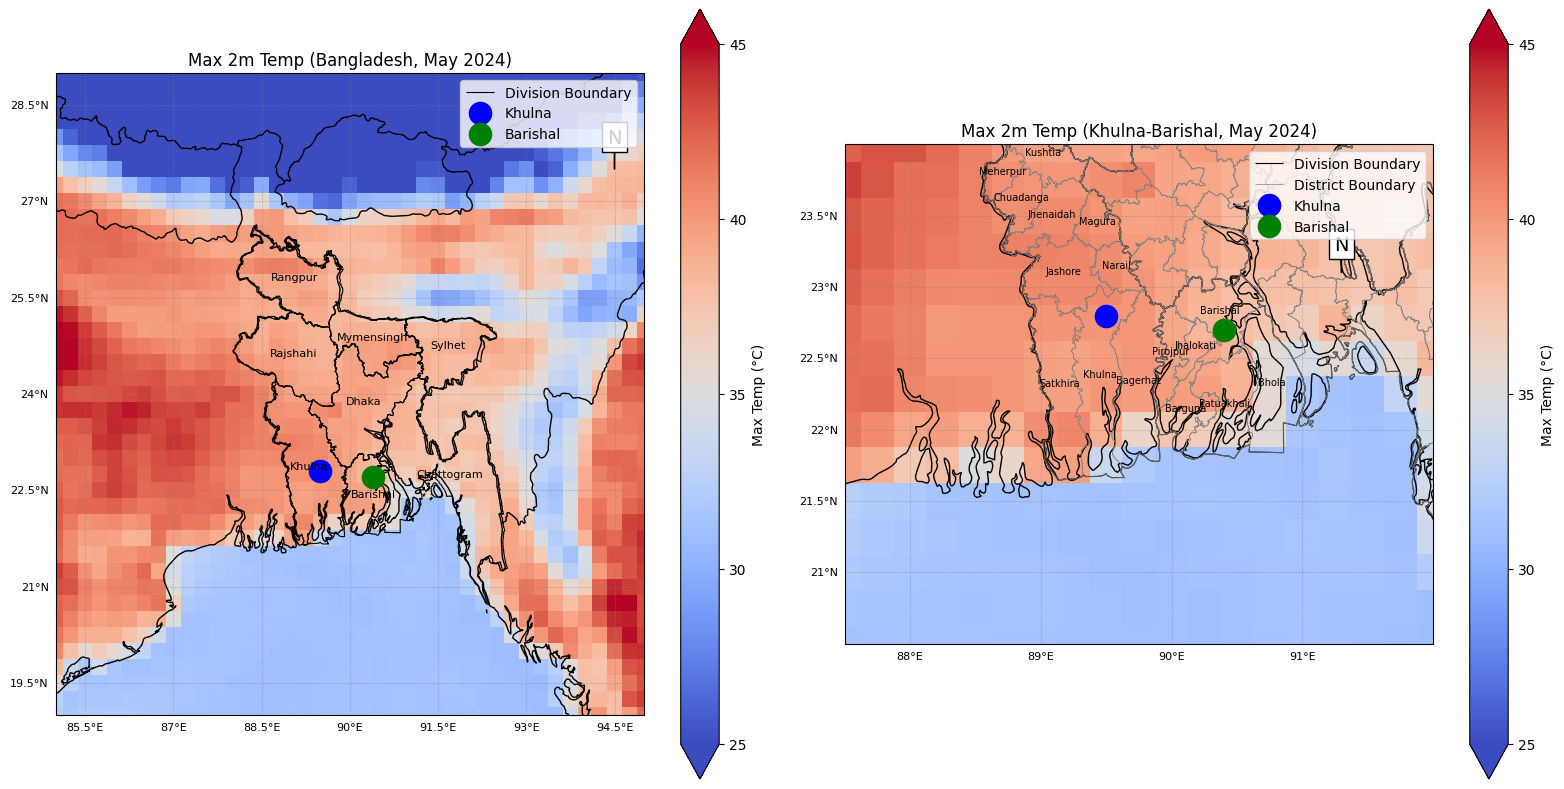

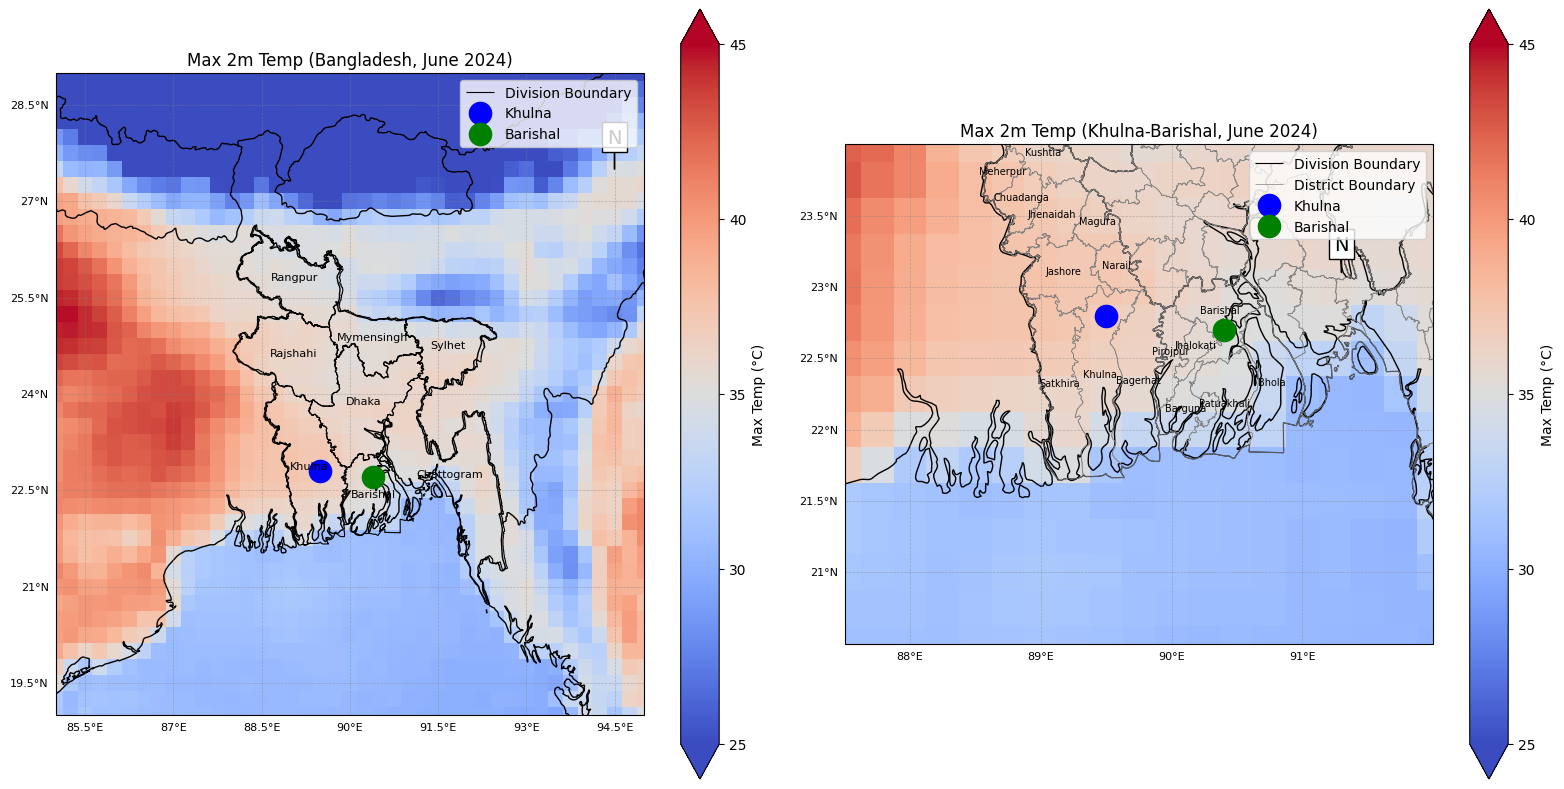

In [44]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# =========================
# Load dataset
# =========================
ds = xr.open_dataset('/content/drive/MyDrive/data_stream-oper_stepType-instant.nc')

# =========================
# Select 2m temperature
# =========================
t2m = ds['t2m']

# =========================
# Division boundaries
# =========================
divisions = gpd.read_file("bgd_admin1.geojson")

# =========================
# District boundaries
# =========================
districts = gpd.read_file("bgd_admin2.geojson")   # এখানে জেলা shapefile দরকার

# =========================
# Monthly ranges (correct dates)
# =========================
months = {
    "March": ("2024-03-01", "2024-03-31"),
    "April": ("2024-04-01", "2024-04-30"),
    "May": ("2024-05-01", "2024-05-31"),
    "June": ("2024-06-01", "2024-06-30")
}

# Fixed scale for all maps
vmin_fixed, vmax_fixed = 25, 45

for month_name, (start_date, end_date) in months.items():
    subset = slice(start_date, end_date)
    t2m_month = t2m.sel(valid_time=subset) - 273.15
    t2m_max = t2m_month.max(dim='valid_time')

    fig, (ax1, ax2) = plt.subplots(1,2, figsize=(16,8), subplot_kw={'projection':ccrs.PlateCarree()})
    lon, lat = np.meshgrid(ds.longitude, ds.latitude)

    # --- Full Bangladesh map ---
    ax1.set_extent([85,95,19,29], crs=ccrs.PlateCarree())
    ax1.coastlines(); ax1.add_feature(cfeature.BORDERS, linestyle='-')
    mesh1 = ax1.pcolormesh(lon, lat, t2m_max, cmap='coolwarm',
                           vmin=vmin_fixed, vmax=vmax_fixed, transform=ccrs.PlateCarree())
    divisions.boundary.plot(ax=ax1, edgecolor="black", linewidth=0.8, label="Division Boundary")
    #districts.boundary.plot(ax=ax1, edgecolor="gray", linewidth=0.5, label="District Boundary")

    # City markers
    ax1.plot(89.5, 22.8, 'o', markersize=16, color='blue', label="Khulna")
    ax1.plot(90.4, 22.7, 'o', markersize=16, color='green', label="Barishal")
    ax1.legend(loc="upper right")
    ax1.set_title(f"Max 2m Temp (Bangladesh, {month_name} 2024)")

    # Division labels
    for idx, row in divisions.iterrows():
        ax1.text(row.geometry.centroid.x, row.geometry.centroid.y,
                 row['adm1_name'], fontsize=8, ha='center', transform=ccrs.PlateCarree())

    # District labels
    #for idx, row in districts.iterrows():
        #ax1.text(row.geometry.centroid.x, row.geometry.centroid.y,
                 #row['adm2_name'], fontsize=6, ha='center', transform=ccrs.PlateCarree())

    # North arrow
    ax1.text(94.5, 28.0, 'N', fontsize=14, ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black'))
    ax1.arrow(94.5, 27.5, 0, 0.4, head_width=0.2, head_length=0.2,
              fc='black', ec='black', transform=ccrs.PlateCarree())

    # Lat–Lon gridlines
    gl1 = ax1.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                        linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl1.top_labels = False
    gl1.right_labels = False
    gl1.xlabel_style = {'size': 8}
    gl1.ylabel_style = {'size': 8}

    # --- Khulna-Barishal zoomed map ---
    ax2.set_extent([87.5,92,20.5,24], crs=ccrs.PlateCarree())
    ax2.coastlines(); ax2.add_feature(cfeature.BORDERS, linestyle='-')
    mesh2 = ax2.pcolormesh(lon, lat, t2m_max, cmap='coolwarm',
                           vmin=vmin_fixed, vmax=vmax_fixed, transform=ccrs.PlateCarree())
    divisions.boundary.plot(ax=ax2, edgecolor="black", linewidth=0.8, label="Division Boundary")
    districts.boundary.plot(ax=ax2, edgecolor="gray", linewidth=0.5, label="District Boundary")

    # City markers
    ax2.plot(89.5, 22.8, 'o', markersize=16, color='blue', label="Khulna")
    ax2.plot(90.4, 22.7, 'o', markersize=16, color='green', label="Barishal")
    ax2.legend(loc="upper right")
    ax2.set_title(f"Max 2m Temp (Khulna-Barishal, {month_name} 2024)")

    # District labels (zoomed)
    target_districts = districts[districts['adm1_name'].isin(["Khulna","Barishal"])]
    for idx, row in target_districts.iterrows():
        ax2.text(row.geometry.centroid.x, row.geometry.centroid.y,
                 row['adm2_name'], fontsize=7, ha='center', transform=ccrs.PlateCarree())

    # North arrow (zoomed)
    ax2.text(91.3, 23.3, 'N', fontsize=14, ha='center', va='center',
             bbox=dict(facecolor='white', edgecolor='black'))
    ax2.arrow(91.3, 23.1, 0, 0.15, head_width=0.05, head_length=0.05,
              fc='black', ec='black', transform=ccrs.PlateCarree())

    # Lat–Lon gridlines (zoomed)
    gl2 = ax2.gridlines(draw_labels=True, crs=ccrs.PlateCarree(),
                        linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl2.top_labels = False
    gl2.right_labels = False
    gl2.xlabel_style = {'size': 8}
    gl2.ylabel_style = {'size': 8}

    # Colorbars
    vmin_fixed = 25
    vmax_fixed = 45
    cbar1 = fig.colorbar(mesh1, ax=ax1, orientation='vertical', extend='both')
    cbar1.set_label("Max Temp (°C)")
    cbar1.set_ticks(np.arange(vmin_fixed, vmax_fixed+1, 5))

    cbar2 = fig.colorbar(mesh2, ax=ax2, orientation='vertical', extend='both')
    cbar2.set_label("Max Temp (°C)")
    cbar2.set_ticks(np.arange(vmin_fixed, vmax_fixed+1, 5))

    plt.tight_layout()
    plt.show()


In [2]:
import pandas as pd

# =========================
# Monthly ranges
# =========================
months = {
    "March": ("2024-03-01", "2024-03-31"),
    "April": ("2024-04-01", "2024-04-30"),
    "May": ("2024-05-01", "2024-05-31"),
    "June": ("2024-06-01", "2024-06-30")
}

records = []
for month_name, (start_date, end_date) in months.items():
    subset = slice(start_date, end_date)
    t2m_month = t2m.sel(valid_time=subset) - 273.15   # Kelvin → Celsius
    t2m_max = t2m_month.max(dim='valid_time')         # monthly max (grid-wise)
    max_val = float(t2m_max.max().values)             # overall max value
    records.append({"Month": month_name, "MaxTemp_C": max_val})

# =========================
# Save to Excel
# =========================
df = pd.DataFrame(records)
df.to_excel("Bangladesh_Max2mTemp_MarJun2024.xlsx", index=False)

print("Excel file saved: Bangladesh_Max2mTemp_MarJun2024.xlsx")


NameError: name 't2m' is not defined